# Task 2 — Plots

In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "matplotlib", "--quiet"])
import pandas as pd, matplotlib.pyplot as plt, glob

def load(folder):
    files = glob.glob(f"{folder}/*.csv")
    return pd.concat([pd.read_csv(f, header=None) for f in files], ignore_index=True)

BASE = "/home/jovyan/python/task2_out"


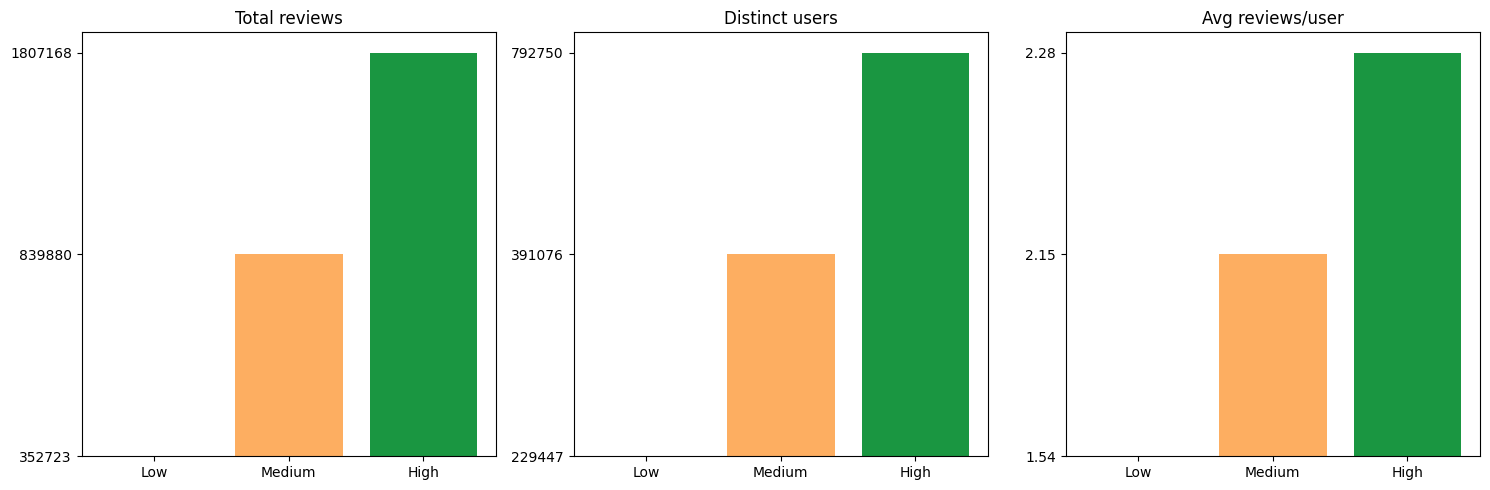

  rating_band total_reviews distinct_users distinct_books pct_total avg_per_user
0         Low        352723         229447          68853     11.76         1.54
1      Medium        839880         391076         127367      28.0         2.15
2        High       1807168         792750         175739     60.24         2.28


In [2]:
q3 = load(f"{BASE}/q3_bands")
q3.columns = ["rating_band","total_reviews","distinct_users","distinct_books","pct_total","avg_per_user"]
q3 = q3.set_index("rating_band").reindex(["Low","Medium","High"]).reset_index()
cols = ["#d7191c","#fdae61","#1a9641"]

fig, axes = plt.subplots(1,3,figsize=(15,5))
axes[0].bar(q3["rating_band"], q3["total_reviews"],  color=cols); axes[0].set_title("Total reviews")
axes[1].bar(q3["rating_band"], q3["distinct_users"], color=cols); axes[1].set_title("Distinct users")
axes[2].bar(q3["rating_band"], q3["avg_per_user"],   color=cols); axes[2].set_title("Avg reviews/user")
plt.tight_layout(); plt.savefig("q3_bands.png", dpi=150); plt.show()
print(q3.to_string())


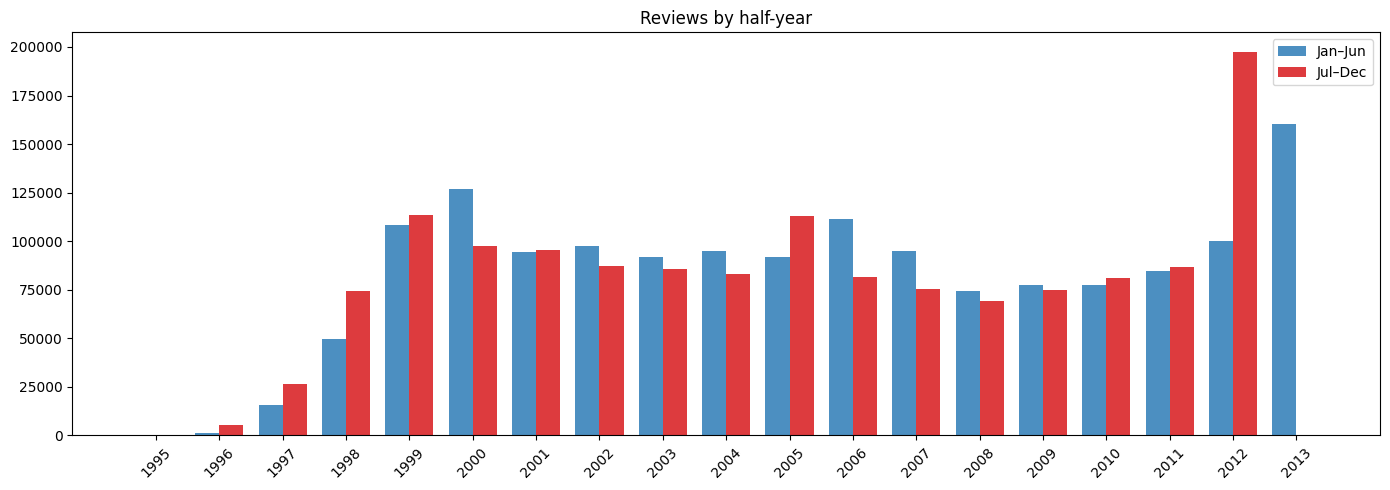

In [6]:
import glob
q4_files = glob.glob(f"{BASE}/q4_time/*.csv")
q4 = pd.concat([pd.read_csv(f, header=0) for f in q4_files], ignore_index=True)
q4.columns = ["year","half_year","total_reviews","avg_score"]
q4["year"] = pd.to_numeric(q4["year"], errors="coerce")
q4 = q4.dropna(subset=["year"])
q4["year"] = q4["year"].astype(int)

early = q4[q4["half_year"]=="Early Year"].set_index("year")
late  = q4[q4["half_year"]=="Late Year"].set_index("year")
yrs = sorted(q4["year"].unique()); x = range(len(yrs)); w = 0.38

fig, ax = plt.subplots(figsize=(14,5))
ax.bar([i-w/2 for i in x],
       [early.loc[y,"total_reviews"] if y in early.index else 0 for y in yrs],
       width=w, label="Jan–Jun", color="#2c7bb6", alpha=0.85)
ax.bar([i+w/2 for i in x],
       [late.loc[y,"total_reviews"] if y in late.index else 0 for y in yrs],
       width=w, label="Jul–Dec", color="#d7191c", alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(yrs, rotation=45)
ax.set_title("Reviews by half-year"); ax.legend()
plt.tight_layout(); plt.savefig("q4_half_year.png", dpi=150); plt.show()

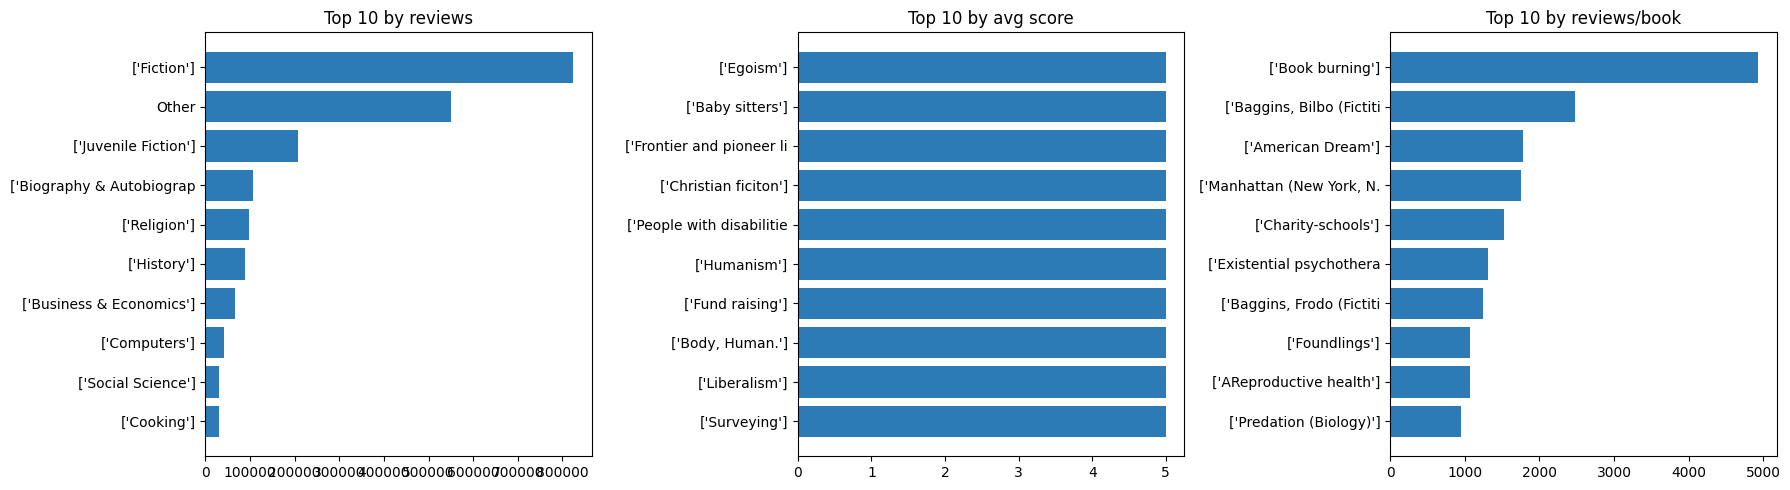

In [8]:
import glob
q5_files = glob.glob(f"{BASE}/q5_categories/*.csv")
q5 = pd.concat([pd.read_csv(f, header=0, quotechar='"', 
                on_bad_lines='skip') for f in q5_files], ignore_index=True)
q5.columns = ["categories","total_reviews","avg_score","distinct_users","distinct_books","avg_per_book"]
q5["total_reviews"] = pd.to_numeric(q5["total_reviews"], errors="coerce")
q5["avg_score"]     = pd.to_numeric(q5["avg_score"], errors="coerce")
q5["avg_per_book"]  = pd.to_numeric(q5["avg_per_book"], errors="coerce")
q5 = q5.dropna(subset=["total_reviews"])

top_rev   = q5.nlargest(10,"total_reviews")
top_score = q5.nlargest(10,"avg_score")
top_apb   = q5.nlargest(10,"avg_per_book")

fig, axes = plt.subplots(1,3,figsize=(18,5))
def hbar(ax,df,col,title):
    ax.barh(df["categories"].str[:25], df[col], color="#2c7bb6")
    ax.set_title(title); ax.invert_yaxis()
hbar(axes[0], top_rev,   "total_reviews",  "Top 10 by reviews")
hbar(axes[1], top_score, "avg_score",       "Top 10 by avg score")
hbar(axes[2], top_apb,   "avg_per_book",    "Top 10 by reviews/book")
plt.tight_layout(); plt.savefig("q5_categories.png", dpi=150); plt.show()

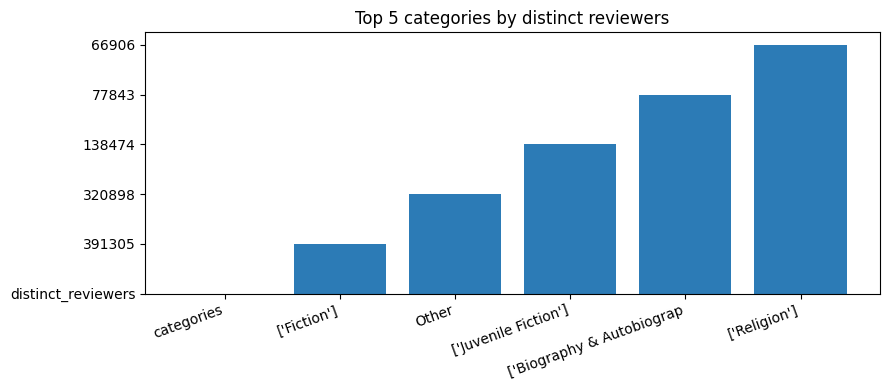

In [9]:
q7b = load(f"{BASE}/q7_cat_reviewers")
q7b.columns = ["categories","distinct_reviewers"]
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(q7b["categories"].str[:25], q7b["distinct_reviewers"], color="#2c7bb6")
ax.set_title("Top 5 categories by distinct reviewers")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig("q7_reviewers.png", dpi=150); plt.show()
